In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob, os
import matplotlib.colors as mcolors


In [2]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')


In [3]:
vdf = []
sdf = []

for i, r in cdf.iterrows():
    ch = r.dataset

    fn = f'../{ch}/{r["sample"]}/scdepth_stability_summary.txt'

    bn = f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt'

    if not os.path.isfile(fn):
        continue

    #df = pd.read_csv(bn, sep='\t').iloc[0]
    bdf = pd.read_csv(fn, sep='\t')
    bdf['group'] = r['group']
    bdf['subgroup'] = r['subgroup']
    bdf['dataset'] = r['dataset']
    bdf['color'] = r['color']
    bdf['title'] = r['subgroup_title']
    bdf['order'] = r['order']
    
    if 'visium_hd' in r['group']:
        vdf.append(bdf)
    else:
        sdf.append(bdf)

vdf = pd.concat(vdf)
sdf = pd.concat(sdf)

vdf['sample_group'] = 'Other FFPE'
vdf.loc[vdf['sample'].str.contains('Lung_Cancer'), 'sample_group'] = 'Lung Cancer FFPE'
vdf.loc[vdf['sample'].str.contains('Tonsil'), 'sample_group'] = 'Tonsil Fresh Frozen'

vdf['sg_color'] = mcolors.to_hex(plt.cm.Dark2.colors[0])

vdf.loc[vdf['sample'].str.contains('Lung_Cancer'), 'sg_color'] = mcolors.to_hex(plt.cm.Dark2.colors[1])
vdf.loc[vdf['sample'].str.contains('Tonsil'), 'sg_color'] = mcolors.to_hex(plt.cm.Dark2.colors[2])



Visium_HD_Human_Breast_Cancer_FFPE
Visium_HD_Human_Kidney_FFPE
Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1
Visium_HD_Human_Lung_Cancer_post_Xenium_Prime_5K_Experiment2
Visium_HD_Human_Lung_Cancer_post_Xenium_v1_Experiment1
Visium_HD_Human_Lymph_Node_FFPE
Visium_HD_Human_Prostate_Cancer_FFPE
Visium_HD_Human_Tonsil_Fresh_Frozen
Visium_HD_Human_Tonsil_Fresh_Frozen_IF
Visium_HD_Mouse_Brain

10k_Human_PBMC_TotalSeqB_singleplex_10k_Human_PBMC_TotalSeqB_singleplex
5k_pbmc_v3
5k_pbmc_v3_nextgem
Kidney_Cancer_PBMC
Kidney_Sarcomatoid_PBMC
Lung_Cancer_PBMC
PBMC_Control1
PBMC_Control2
PBMC_F1A_10X_3p_v31
PBMC_F1A_10X_flex_v1
PBMC_F1B_10X_3p_v31
PBMC_F1B_10X_flex_v1
PBMC_F5A_10X_3p_v31
PBMC_F5A_10X_flex_v1
PBMC_F5B_10X_3p_v31
PBMC_F5B_10X_flex_v1
Parent_NGSC3_DI_PBMC
SC3_v3_NextGem_DI_PBMC_10K
SC3_v3_NextGem_DI_PBMC_CSP_1K
SC3_v3_NextGem_SI_PBMC_10K
SC3_v3_NextGem_SI_PBMC_CSP_1K
connect_5k_pbmc_NGSC3_ch1
manual_5k_pbmc_NGSC3_ch1
manual_5k_pbmc_NGSC3_ch5
pbmc_10k_protein_v3
pbmc_10k_v3
pbmc_1k_p

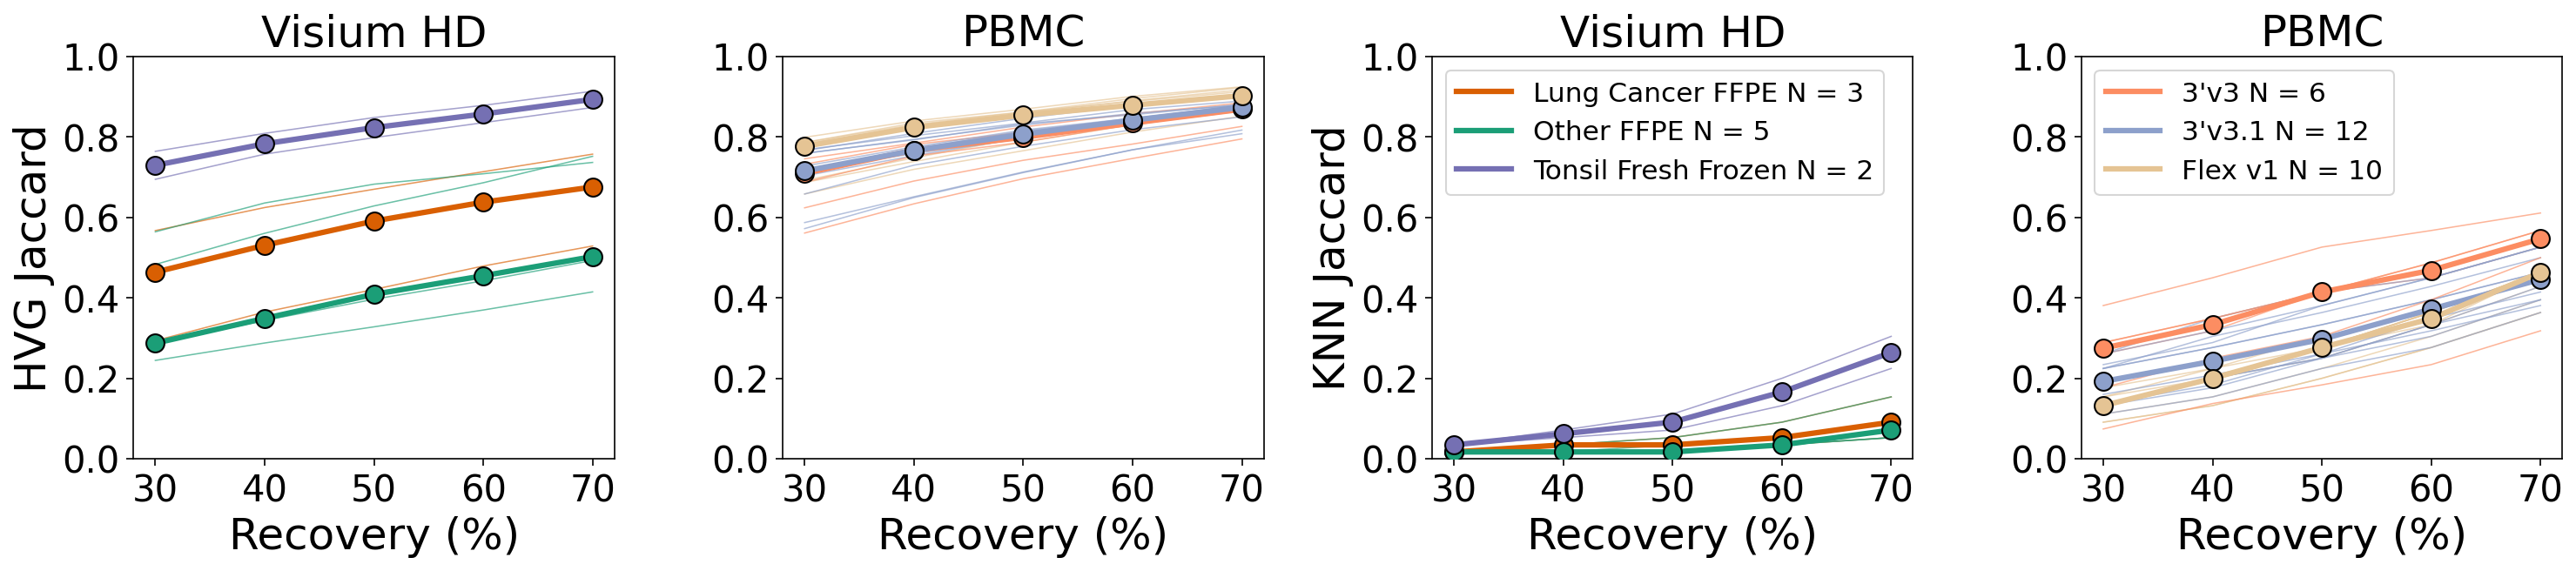

In [4]:
fig, axs = pl.figax(1, 4, w=6, h=4)
fig.subplots_adjust(wspace=0.35)

keys = ['hvg_jaccard_median', 'knn_jaccard_median', ]
ai = 0
for k in keys:
    for df, sg, col, ti in zip((vdf, sdf), ('sample_group',  'subgroup'), ('sg_color', 'color'), ('sample_group', 'title')):
        ax = axs[ai]
        for s, d in df.groupby('sample'):
            print(s)
            ax.plot(d['recovery'], d[k], ls='-', lw=0.75, color=d[col].values[0], alpha=0.65, zorder=3)
        for l, d in df.groupby(sg):
            gmed = d[['recovery'] + keys].groupby('recovery').median()
            ax.plot(gmed.index.values, gmed[k], lw=3, color=d[col].values[0], zorder=4, label=f"{d[ti].values[0]} N = {len(d['sample'].unique())}")
            ax.scatter(gmed.index.values, gmed[k], lw=1, edgecolor='k', s=100, color=d[col].values[0], zorder=5)
        ai += 1
        print('')

for ax in axs:
    ax.set_xlabel('Recovery (%)', fontsize=24)
    ax.tick_params(axis='both', which='both', length=4)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_ylim(0, 1)
    #ax.set_box_aspect(1)
    ax.set_xticks(np.arange(30, 75, 10))
    

#axs[2].set_ylabel('Cluster ARI', fontsize=15)
axs[2].set_ylabel('KNN Jaccard', fontsize=24)
axs[0].set_ylabel('HVG Jaccard', fontsize=24)
axs[2].legend(loc = 'upper left', fontsize=15)
axs[3].legend(loc = 'upper left', fontsize=15)
axs[0].set_title('Visium HD', fontsize=24)
axs[1].set_title('PBMC', fontsize=24)
axs[2].set_title('Visium HD', fontsize=24)
axs[3].set_title('PBMC', fontsize=24)

fig.savefig('../Figures/Figure S8 HVG KNN.svg', bbox_inches='tight') 

[<Axes: > <Axes: > <Axes: >]
[<Axes: > <Axes: > <Axes: >]
[<Axes: > <Axes: > <Axes: >]
[<Axes: > <Axes: > <Axes: >]
[<Axes: > <Axes: > <Axes: >]
[<Axes: > <Axes: > <Axes: >]


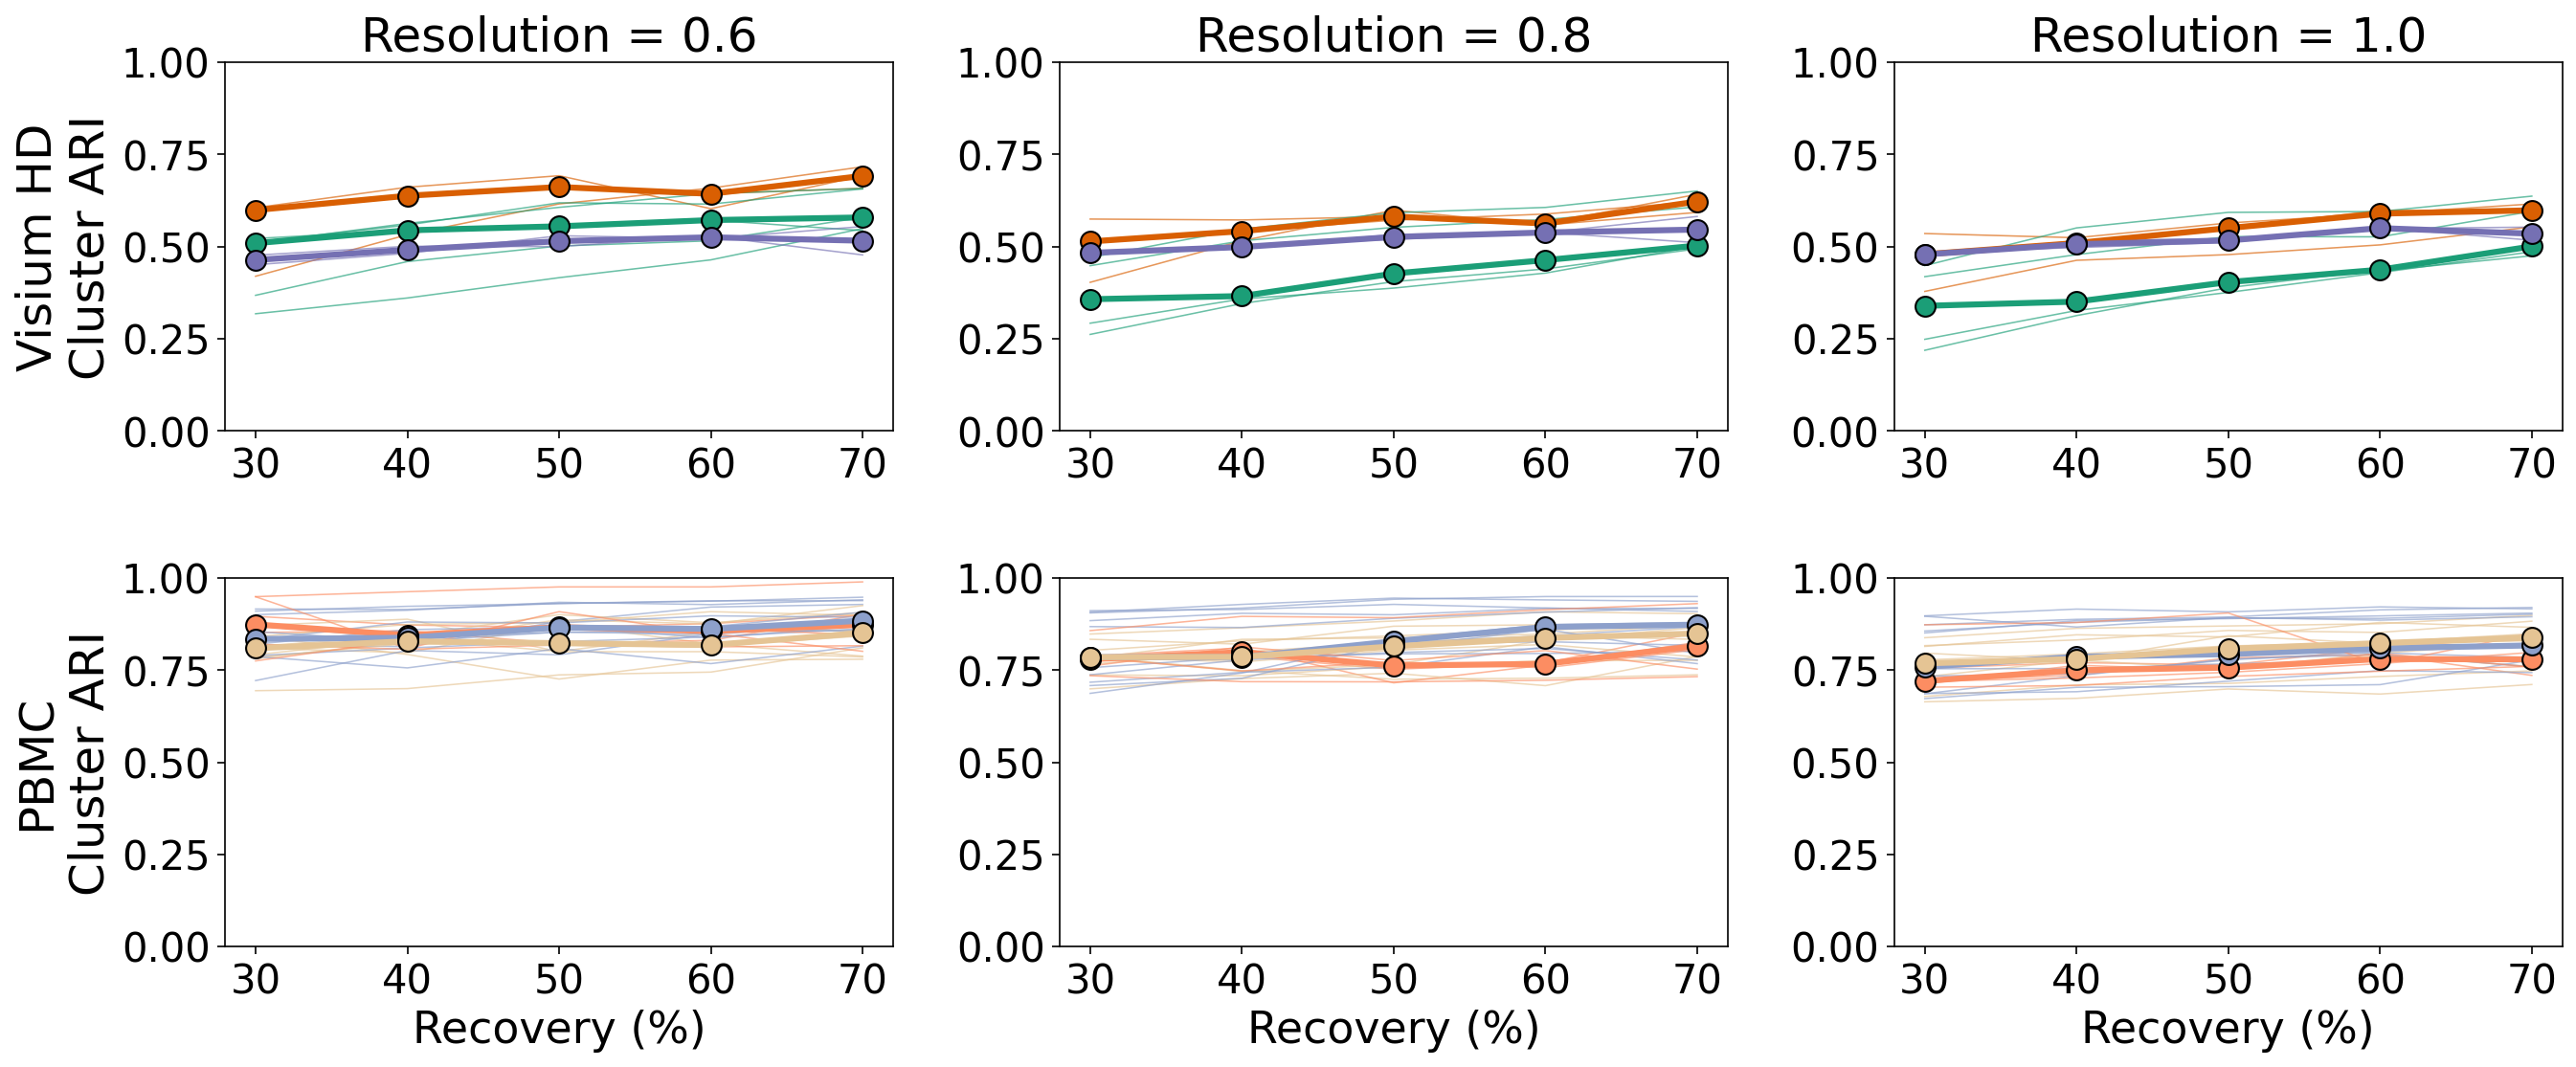

In [5]:
fig, raxs = pl.figax(2, 3, w=7, h=4)
fig.subplots_adjust(wspace=0.25, hspace=0.40)

keys = ['ari_median_res0p6', 'ari_median_res0p8', 'ari_median_res1p0']
for df, axs, sg, col in zip((vdf, sdf), raxs, ('sample_group',  'subgroup'), ('sg_color', 'color')):
    ai = 0

    for k in keys:
        print(axs)
        ax = axs[ai]
        for s, d in df.groupby('sample'):
             ax.plot(d['recovery'], d[k], ls='-', lw=0.75, color=d[col].values[0], alpha=0.65, zorder=3)
        for l, d in df.groupby(sg):
            gmed = d[['recovery'] + keys].groupby('recovery').median()
            ax.plot(gmed.index.values, gmed[k], lw=3, color=d[col].values[0], zorder=4, label=f"{d['title'].values[0]} N = {len(d['sample'].unique())}")
            ax.scatter(gmed.index.values, gmed[k], lw=1, edgecolor='k', s=100, color=d[col].values[0], zorder=5)
        ai += 1

for ax in raxs.flatten():
    ax.tick_params(axis='both', which='both', length=4)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(30, 75, 10))
for ax in raxs[1]:
    ax.set_xlabel('Recovery (%)', fontsize=22)
    



raxs[0,0].set_ylabel('Visium HD\nCluster ARI', fontsize=24)
raxs[1,0].set_ylabel('PBMC\nCluster ARI', fontsize=24)
for ax, lab in zip(raxs[0], ('Resolution = 0.6', 'Resolution = 0.8', 'Resolution = 1.0',)):
    ax.set_title(lab, fontsize=24)
fig.savefig('../Figures/Figure S8 Cluster ARI.svg', bbox_inches='tight') 